# Plot saved timescales

Use matlab script to calculate timescales for each model, so plot the saved ones here

In [1]:
import numpy as np 
import sys
from matplotlib import pyplot as plt
import matplotlib.patches as patches
import scipy
import os
import importlib
import pandas as pd

sys.path.append('/home/nuttidalab/Documents/spikeRNN/analysis/utils')
import load_data as ld 
import single_neuron_utils as sn 
from bootstrap_method import *


In [2]:
delay = 150
condn_phrase = 'delay'
condn_num = 150

# condn_key = f'{condn_phrase}{condn_num}'

In [3]:
# find folder names within model directory
all_models_dir = '/scratch/all_DMS_models/'

model_dirs = ld.get_immediate_subdirs(all_models_dir)
print(model_dirs)


['Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_152659']


In [4]:
# choose model 0 to visualize for now
model_name = model_dirs[0]
model_dir = os.path.join(all_models_dir, model_name)

# find files for this delay of interest
data_files = ld.find_files_keywords(model_dir, [f'delay{delay}'])

## Load the timescales

In [23]:
importlib.reload(ld)
mean_decay, taus_decay_ms, auto_N = ld.get_timescales(model_name)
print(mean_decay)
print(taus_decay_ms.shape)
print(auto_N.shape)

153.393172059439
(26,)
(26,)


In [24]:
auto_N

array([  3,  36,  63,  68,  85,  88, 107, 111, 115, 117, 121, 126, 129,
       130, 137, 141, 145, 157, 165, 168, 175, 178, 179, 186, 191, 195])

### some plotting

In [15]:
exc_ind, inh_ind = ld.get_celltype_label(model_name)

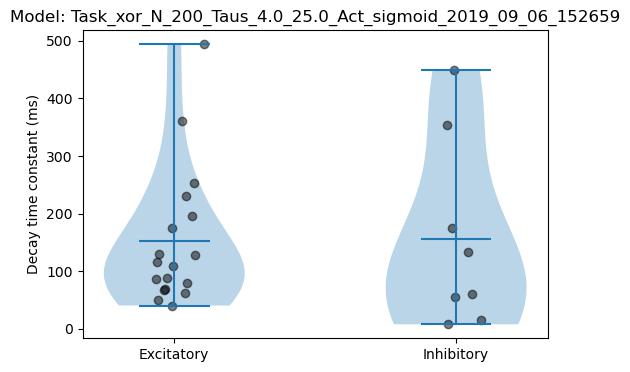

In [30]:
plt.figure(figsize=(6,4))
exc_auto_inds = [i for i in range(len(auto_N)) if auto_N[i] in exc_ind]
inh_auto_inds = [i for i in range(len(auto_N)) if auto_N[i] in inh_ind]

# make violin plot with scatter points inside
plt.violinplot([taus_decay_ms[exc_auto_inds], taus_decay_ms[inh_auto_inds]], showmeans=True)
plt.scatter(np.random.normal(1, 0.05, len(exc_auto_inds)), taus_decay_ms[exc_auto_inds], color='black', alpha=0.5)
plt.scatter(np.random.normal(2, 0.05, len(inh_auto_inds)), taus_decay_ms[inh_auto_inds], color='black', alpha=0.5)
plt.xticks([1, 2], ['Excitatory', 'Inhibitory'])
plt.ylabel('Decay time constant (ms)')
plt.title(f'Model: {model_name}')
plt.show()